# Analyse de la consommation

Ce notebook charge `brest_metropole_daily.csv` dans un DataFrame pandas puis affiche l'évolution de `conso_mwh` en fonction de `date`.

In [3]:
import requests
import pandas as pd
from datetime import date, timedelta

BASE = "https://odre.opendatasoft.com/api/explore/v2.1/catalog/datasets"
DATASET = "eco2mix-metropoles-tr"
URL = f"{BASE}/{DATASET}/records"

EPCI = "242900314"

date_debut = date.today() - timedelta(days=6 * 365)
annee_debut = date_debut.year
annee_fin = date.today().year

all_rows = []

for year in range(annee_debut, annee_fin + 1):
    for month in range(1, 13):
        start = f"{year}-{month:02d}-01T00:00:00+00:00"

        if month == 12:
            end = f"{year + 1}-01-01T00:00:00+00:00"
        else:
            end = f"{year}-{month + 1:02d}-01T00:00:00+00:00"

        params = {
            "where": (
                f"code_insee_epci = '{EPCI}' "
                f"AND date_heure >= date'{start}' "
                f"AND date_heure < date'{end}'"
            ),
            "limit": 100,
            "offset": 0,
            "order_by": "date_heure",
        }

        mois_label = f"{year}-{month:02d}"
        month_rows = 0
        page_count = 0
        print(f"[{mois_label}] debut")

        while True:
            r = requests.get(URL, params=params, timeout=30)

            if r.status_code != 200:
                print("Erreur", r.status_code, start, end, params["offset"])
                print(r.text)
                break

            rows = r.json().get("results", [])
            all_rows.extend(rows)
            month_rows += len(rows)
            page_count += 1

            if len(rows) < params["limit"]:
                break

            params["offset"] += params["limit"]

        print(f"[{mois_label}] {month_rows} lignes recuperees ({page_count} page(s))")

if not all_rows:
    raise RuntimeError("Aucune donnée récupérée")

df = pd.DataFrame(all_rows)

df["date_heure"] = pd.to_datetime(df["date_heure"], utc=True)
df["date"] = df["date_heure"].dt.date
df["consommation"] = pd.to_numeric(df["consommation"], errors="coerce")

df_daily = (
    df.dropna(subset=["consommation"])
    .groupby("date", as_index=False)
    .agg(
        conso_moy_mw=("consommation", "mean"),
        conso_min_mw=("consommation", "min"),
        conso_max_mw=("consommation", "max"),
        nb_mesures=("consommation", "count"),
    )
)

df_daily["conso_mwh"] = df_daily["conso_moy_mw"] * 24

df_daily.to_csv("brest_metropole_daily.csv", index=False)

print(df_daily.head())
print(df_daily.tail())
print(df_daily.shape)


[2020-01] debut
[2020-01] 2976 lignes recuperees (30 page(s))
[2020-02] debut
[2020-02] 2784 lignes recuperees (28 page(s))
[2020-03] debut
[2020-03] 2980 lignes recuperees (30 page(s))
[2020-04] debut
[2020-04] 2880 lignes recuperees (29 page(s))
[2020-05] debut
[2020-05] 2976 lignes recuperees (30 page(s))
[2020-06] debut
[2020-06] 2880 lignes recuperees (29 page(s))
[2020-07] debut
[2020-07] 2976 lignes recuperees (30 page(s))
[2020-08] debut
[2020-08] 2976 lignes recuperees (30 page(s))
[2020-09] debut
[2020-09] 2880 lignes recuperees (29 page(s))
[2020-10] debut
[2020-10] 2972 lignes recuperees (30 page(s))
[2020-11] debut
[2020-11] 2880 lignes recuperees (29 page(s))
[2020-12] debut
[2020-12] 2976 lignes recuperees (30 page(s))
[2021-01] debut
[2021-01] 2976 lignes recuperees (30 page(s))
[2021-02] debut
[2021-02] 2688 lignes recuperees (27 page(s))
[2021-03] debut
[2021-03] 2980 lignes recuperees (30 page(s))
[2021-04] debut
[2021-04] 2880 lignes recuperees (29 page(s))
[2021-05

In [4]:
import requests
import pandas as pd
from datetime import date, timedelta

# Coordonnees de Brest
LATITUDE = 48.3904
LONGITUDE = -4.4861

if "df_daily" in globals() and not df_daily.empty:
    start_date = pd.to_datetime(df_daily["date"]).min().date()
    end_date = pd.to_datetime(df_daily["date"]).max().date()
else:
    end_date = date.today()
    start_date = end_date - timedelta(days=6 * 365)

meteo_url = "https://archive-api.open-meteo.com/v1/archive"
meteo_params = {
    "latitude": LATITUDE,
    "longitude": LONGITUDE,
    "start_date": start_date.isoformat(),
    "end_date": end_date.isoformat(),
    "timezone": "Europe/Paris",
    "daily": ",".join(
        [
            "temperature_2m_mean",
            "temperature_2m_max",
            "temperature_2m_min",
            "relative_humidity_2m_mean",
            "precipitation_sum",
            "wind_speed_10m_max",
        ]
    ),
}

r_meteo = requests.get(meteo_url, params=meteo_params, timeout=30)
r_meteo.raise_for_status()
meteo_json = r_meteo.json()

if "daily" not in meteo_json:
    raise RuntimeError("Reponse Open-Meteo invalide: champ 'daily' absent")

df_meteo_daily = pd.DataFrame(meteo_json["daily"]).rename(
    columns={
        "time": "date",
        "temperature_2m_mean": "temp_moy_c",
        "temperature_2m_max": "temp_max_c",
        "temperature_2m_min": "temp_min_c",
        "relative_humidity_2m_mean": "humidite_moy_pct",
        "precipitation_sum": "precip_mm",
        "wind_speed_10m_max": "vent_max_kmh",
    }
)

df_meteo_daily["date"] = pd.to_datetime(df_meteo_daily["date"])
df_meteo_daily = df_meteo_daily.sort_values("date").reset_index(drop=True)

df_meteo_daily.to_csv("brest_meteo_daily.csv", index=False)

print(f"Meteo recuperee du {start_date} au {end_date}")
print(df_meteo_daily.head())
print(df_meteo_daily.tail())
print(df_meteo_daily.shape)


Meteo recuperee du 2020-01-01 au 2026-06-01
        date  temp_moy_c  temp_max_c  temp_min_c  humidite_moy_pct  precip_mm  \
0 2020-01-01         9.4        10.9         8.0                96        0.0   
1 2020-01-02        10.0        11.2         7.1                92        1.2   
2 2020-01-03         9.6        11.6         6.2                86        1.4   
3 2020-01-04         7.0         9.6         4.3                81        0.0   
4 2020-01-05         7.3         8.4         6.6                84        0.0   

   vent_max_kmh  
0           9.8  
1          29.9  
2          30.3  
3           9.9  
4          18.8  
           date  temp_moy_c  temp_max_c  temp_min_c  humidite_moy_pct  \
2339 2026-05-28        21.2        27.4        15.9                67   
2340 2026-05-29        16.8        22.8        14.2                80   
2341 2026-05-30        17.0        21.2        13.7                76   
2342 2026-05-31        16.7        19.1        14.2                78

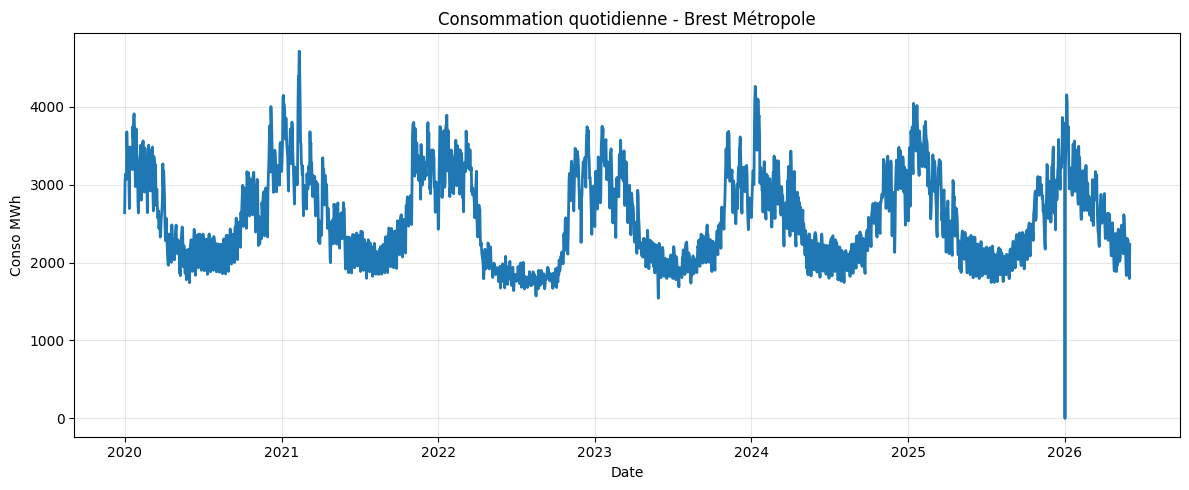

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('brest_metropole_daily.csv', parse_dates=['date'])
df = df.sort_values('date')

plt.figure(figsize=(12, 5))
plt.plot(df['date'], df['conso_mwh'], color='#1f77b4', linewidth=2)
plt.title('Consommation quotidienne - Brest Métropole')
plt.xlabel('Date')
plt.ylabel('Conso MWh')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

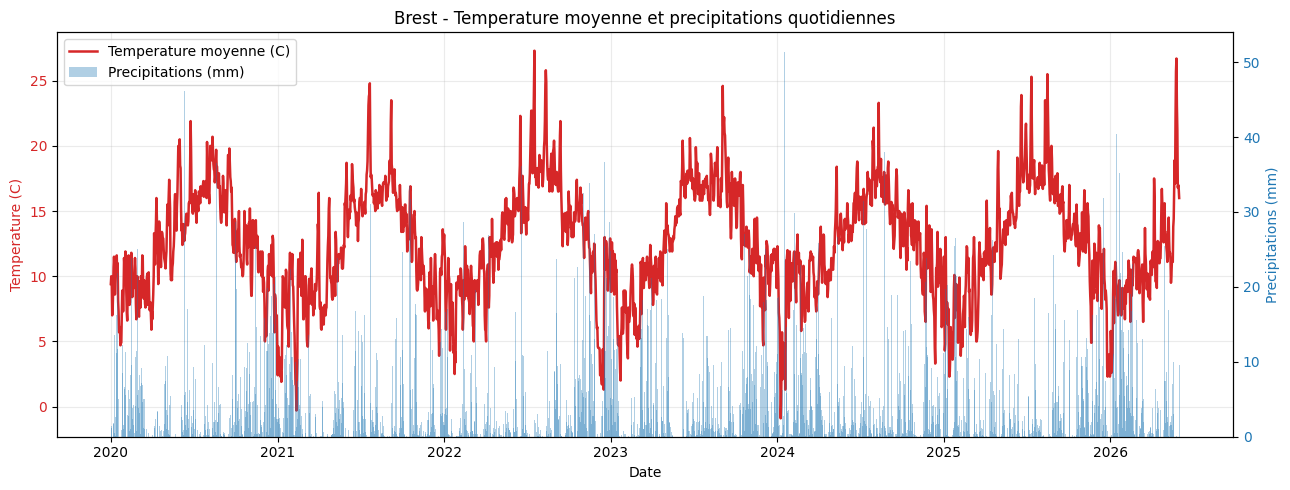

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

if "df_meteo_daily" in globals() and not df_meteo_daily.empty:
    meteo_plot = df_meteo_daily.copy()
else:
    meteo_plot = pd.read_csv("brest_meteo_daily.csv", parse_dates=["date"])

meteo_plot = meteo_plot.sort_values("date")

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.plot(
    meteo_plot["date"],
    meteo_plot["temp_moy_c"],
    color="#d62728",
    linewidth=1.8,
    label="Temperature moyenne (C)",
)
ax1.set_xlabel("Date")
ax1.set_ylabel("Temperature (C)", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")
ax1.grid(True, alpha=0.25)

ax2 = ax1.twinx()
ax2.bar(
    meteo_plot["date"],
    meteo_plot["precip_mm"],
    width=2.0,
    color="#1f77b4",
    alpha=0.35,
    label="Precipitations (mm)",
)
ax2.set_ylabel("Precipitations (mm)", color="#1f77b4")
ax2.tick_params(axis="y", labelcolor="#1f77b4")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.title("Brest - Temperature moyenne et precipitations quotidiennes")
fig.tight_layout()
plt.show()

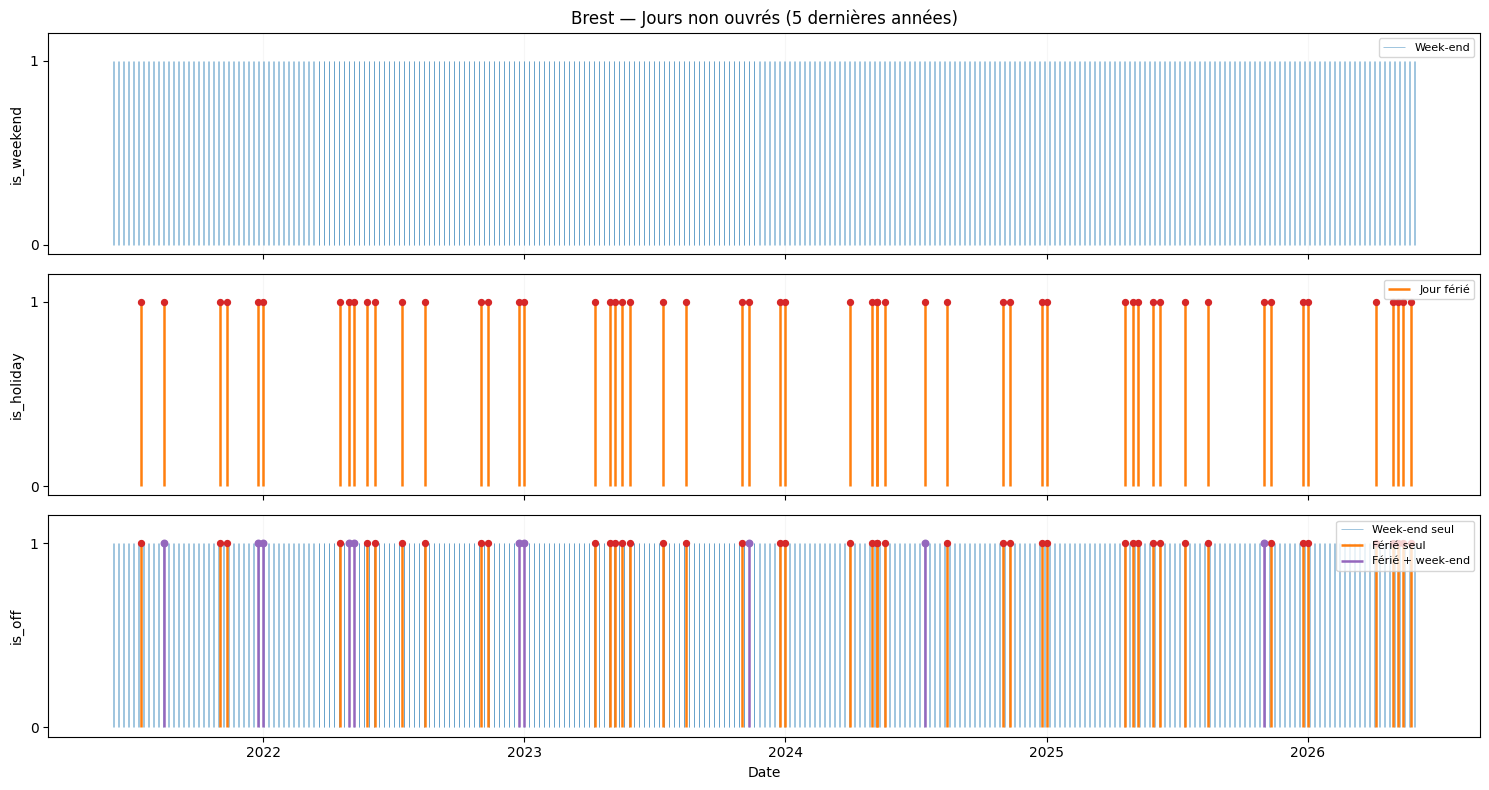

        date  is_holiday  is_weekend  is_off
0 2020-01-01           1           0       1
1 2020-01-02           0           0       0
2 2020-01-03           0           0       0
3 2020-01-04           0           1       1
4 2020-01-05           0           1       1
           date  is_holiday  is_weekend  is_off
2340 2026-05-29           0           0       0
2341 2026-05-30           0           1       1
2342 2026-05-31           0           1       1
2343 2026-06-01           0           0       0
2344 2026-06-02           0           0       0
is_weekend    670
is_holiday     72
is_off        728
dtype: int64
(2345, 4)


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date
import holidays

start_date_cal = pd.Timestamp("2020-01-01")
end_date_cal = pd.Timestamp(date.today())

df_calendar = pd.DataFrame({
    "date": pd.date_range(start=start_date_cal, end=end_date_cal, freq="D")
})

fr_holidays = holidays.country_holidays("FR", years=range(start_date_cal.year, end_date_cal.year + 1))
is_weekend = df_calendar["date"].dt.weekday >= 5
is_holiday = df_calendar["date"].dt.date.isin(fr_holidays)

df_calendar["is_holiday"] = is_holiday.astype(int)
df_calendar["is_weekend"] = is_weekend.astype(int)
df_calendar["is_off"] = (is_weekend | is_holiday).astype(int)

df_calendar.to_csv("brest_calendar_off_days.csv", index=False)

# Graphe sur les 5 dernières années
start_5y = end_date_cal - pd.DateOffset(years=5)
df_plot = df_calendar[df_calendar["date"] >= start_5y].copy()

weekend_dates  = df_plot.loc[df_plot["is_weekend"] == 1, "date"]
holiday_dates  = df_plot.loc[df_plot["is_holiday"] == 1, "date"]

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True)

# --- Subplot 1 : week-ends ---
axes[0].vlines(weekend_dates, ymin=0, ymax=1, color="#1f77b4", linewidth=0.6, alpha=0.5, label="Week-end")
axes[0].set_ylim(-0.05, 1.15)
axes[0].set_yticks([0, 1])
axes[0].set_ylabel("is_weekend")
axes[0].set_title("Brest — Jours non ouvrés (5 dernières années)")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].grid(axis="x", alpha=0.1)

# --- Subplot 2 : jours fériés ---
axes[1].vlines(holiday_dates, ymin=0, ymax=1, color="#ff7f0e", linewidth=1.8, label="Jour férié")
axes[1].scatter(holiday_dates, [1] * len(holiday_dates), color="#d62728", s=18, zorder=3)
axes[1].set_ylim(-0.05, 1.15)
axes[1].set_yticks([0, 1])
axes[1].set_ylabel("is_holiday")
axes[1].legend(loc="upper right", fontsize=8)
axes[1].grid(axis="x", alpha=0.1)

# --- Subplot 3 : is_off combiné (week-end OU férié) ---
off_dates     = df_plot.loc[df_plot["is_off"] == 1, "date"]
we_only_dates = df_plot.loc[(df_plot["is_weekend"] == 1) & (df_plot["is_holiday"] == 0), "date"]
holiday_only  = df_plot.loc[(df_plot["is_holiday"] == 1) & (df_plot["is_weekend"] == 0), "date"]
both_dates    = df_plot.loc[(df_plot["is_holiday"] == 1) & (df_plot["is_weekend"] == 1), "date"]

axes[2].vlines(we_only_dates,   ymin=0, ymax=1, color="#1f77b4", linewidth=0.6, alpha=0.5, label="Week-end seul")
axes[2].vlines(holiday_only,    ymin=0, ymax=1, color="#ff7f0e", linewidth=1.8,             label="Férié seul")
axes[2].vlines(both_dates,      ymin=0, ymax=1, color="#9467bd", linewidth=1.8,             label="Férié + week-end")
axes[2].scatter(holiday_only,   [1] * len(holiday_only),  color="#d62728", s=18, zorder=3)
axes[2].scatter(both_dates,     [1] * len(both_dates),    color="#9467bd", s=22, zorder=3)
axes[2].set_ylim(-0.05, 1.15)
axes[2].set_yticks([0, 1])
axes[2].set_ylabel("is_off")
axes[2].set_xlabel("Date")
axes[2].legend(loc="upper right", fontsize=8)
axes[2].grid(axis="x", alpha=0.1)

plt.tight_layout()
plt.show()

print(df_calendar.head())
print(df_calendar.tail())
print(df_calendar[["is_weekend", "is_holiday", "is_off"]].sum())
print(df_calendar.shape)

In [8]:
# calendrier férié

In [9]:
import requests
import pandas as pd
from datetime import date

URL = (
    "https://public.opendatasoft.com/api/explore/v2.1/"
    "catalog/datasets/population-francaise-communes/records"
)

where_clause = "code_epci='242900314'"

all_rows = []
offset = 0
limit = 100

while True:
    params = {
        "limit": limit,
        "offset": offset,
        "where": where_clause,
        "select": "annee_utilisation,population_totale",
    }

    r = requests.get(URL, params=params, timeout=30)
    r.raise_for_status()

    rows = r.json().get("results", [])
    if not rows:
        break

    all_rows.extend(rows)

    if len(rows) < limit:
        break

    offset += limit

if not all_rows:
    raise RuntimeError("Aucune donnee population recuperee")

df_pop_raw = pd.DataFrame(all_rows)
df_pop_raw["annee_utilisation"] = pd.to_numeric(df_pop_raw["annee_utilisation"], errors="coerce")
df_pop_raw["population_totale"] = pd.to_numeric(df_pop_raw["population_totale"], errors="coerce")
df_pop_raw = df_pop_raw.dropna(subset=["annee_utilisation", "population_totale"])

# Population annuelle EPCI = somme des communes par annee
df_pop_yearly = (
    df_pop_raw.groupby("annee_utilisation", as_index=False)["population_totale"]
    .sum()
    .rename(columns={"annee_utilisation": "year", "population_totale": "population_epci"})
    .sort_values("year")
)
df_pop_yearly["year"] = df_pop_yearly["year"].astype(int)
df_pop_yearly["population_epci"] = df_pop_yearly["population_epci"].round().astype(int)

# Base annuelle au 1er janvier de chaque annee
df_year_points = df_pop_yearly.copy()

date_min = pd.Timestamp("2020-01-01")
date_max = pd.Timestamp(date.today())

# Si l'annee courante depasse les donnees disponibles, extrapolation sur le dernier delta annuel
while df_year_points["year"].max() < date_max.year:
    last_two = df_year_points.tail(2)
    if len(last_two) < 2:
        next_pop = int(df_year_points.iloc[-1]["population_epci"])
    else:
        annual_delta = int(last_two.iloc[-1]["population_epci"] - last_two.iloc[-2]["population_epci"])
        next_pop = int(last_two.iloc[-1]["population_epci"] + annual_delta)

    next_year = int(df_year_points.iloc[-1]["year"] + 1)
    df_year_points = pd.concat(
        [
            df_year_points,
            pd.DataFrame([{"year": next_year, "population_epci": next_pop}]),
        ],
        ignore_index=True,
    )

year_points = {
    int(row["year"]): float(row["population_epci"])
    for _, row in df_year_points.iterrows()
}

all_dates = pd.date_range(start=date_min, end=date_max, freq="D")
rows_daily = []

for d in all_dates:
    y = d.year
    day_idx = d.timetuple().tm_yday - 1

    pop_y = year_points.get(y)
    pop_next = year_points.get(y + 1, pop_y)

    if pop_y is None:
        continue

    pop_daily = pop_y + (pop_next - pop_y) * (day_idx / 365.0)

    rows_daily.append(
        {
            "date": d,
            "population_daily_est": int(round(pop_daily)),
        }
    )

df_population_daily = pd.DataFrame(rows_daily)
df_population_daily = df_population_daily.sort_values("date").reset_index(drop=True)

df_population_daily.to_csv("brest_population_daily_est.csv", index=False)

df_pop_yearly.to_csv("brest_population_yearly.csv", index=False)

print("Population annuelle (source agregee):")
print(df_pop_yearly)
print("\nPopulation quotidienne estimee:")
print(df_population_daily.head())
print(df_population_daily.tail())
print(df_population_daily.shape)


Population annuelle (source agregee):
   year  population_epci
0  2015           212891
1  2016           213171
2  2017           212998
3  2018           213462
4  2019           213880

Population quotidienne estimee:
        date  population_daily_est
0 2020-01-01                214298
1 2020-01-02                214299
2 2020-01-03                214300
3 2020-01-04                214301
4 2020-01-05                214303
           date  population_daily_est
2340 2026-05-29                216806
2341 2026-05-30                216806
2342 2026-05-31                216806
2343 2026-06-01                216806
2344 2026-06-02                216806
(2345, 2)


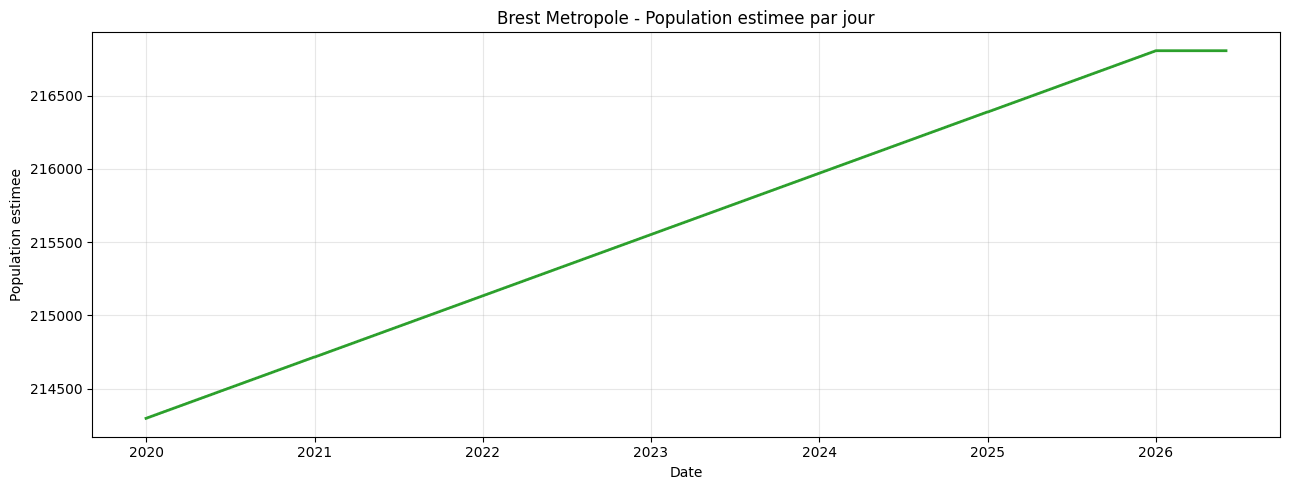

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

if "df_population_daily" in globals() and not df_population_daily.empty:
    pop_plot = df_population_daily.copy()
else:
    pop_plot = pd.read_csv("brest_population_daily_est.csv", parse_dates=["date"])

pop_plot = pop_plot.sort_values("date")

plt.figure(figsize=(13, 5))
plt.plot(
    pop_plot["date"],
    pop_plot["population_daily_est"],
    color="#2ca02c",
    linewidth=2,
)
plt.title("Brest Metropole - Population estimee par jour")
plt.xlabel("Date")
plt.ylabel("Population estimee")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=40773.259, Time=-1.38 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.04 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=inf, Time=0.31 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=29776.109, Time=0.09 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=29710.532, Time=0.63 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.07 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=29472.762, Time=1.95 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.09 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=29465.528, Time=2.77 sec
 ARIMA(4,0,0)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(5,0,1)(0,0,0)[0]             : AIC=29409.898, Time=3.41 sec
 ARIMA(5,0,0)(0,0,0)[0]             : AIC=inf, Time=0.16 sec
 ARIMA(5,0,2)(0,0,0)[0]             : AIC=inf, Time=4.35 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=29130.147, Time=2.26 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=29434.773, Time=0.

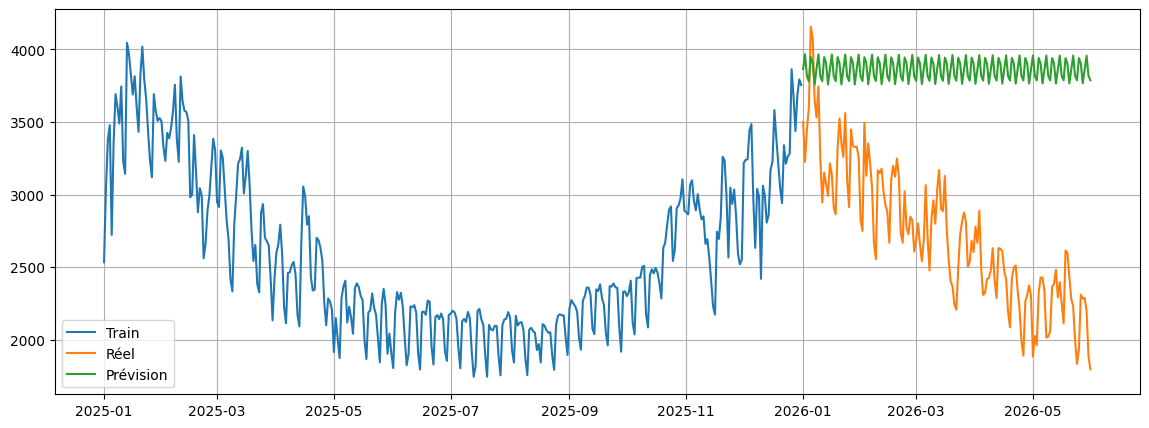

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PREPARATION

df = pd.read_csv("data/brest_metropole_daily.csv")

df["date"] = pd.to_datetime(df["date"])

df = (
    df.sort_values("date")
      .set_index("date")
)

ts = df["conso_mwh"]

# SPLIT

train = ts.loc["2020-01-01":"2025-12-31"]
valid = ts.loc["2026-01-01":]

# Recherche automatique

model_a1 = auto_arima(
    train,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    seasonal=False,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True
)

print(model_a1.summary())

# Prévision

forecast = model_a1.predict(
    n_periods=len(valid)
)

forecast = pd.Series(
    forecast,
    index=valid.index
)

# Évaluation

mae = mean_absolute_error(valid, forecast)
rmse = np.sqrt(mean_squared_error(valid, forecast))

mape = (
    np.abs((valid - forecast) / valid)
    .mean()
    * 100
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Visualisation

plt.figure(figsize=(14, 5))

plt.plot(train.loc["2025-01-01":], label="Train")
plt.plot(valid, label="Réel")
plt.plot(forecast, label="Prévision")

plt.legend()
plt.grid()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=29273.221, Time=0.10 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=28666.955, Time=1.88 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=28011.840, Time=3.49 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=29274.899, Time=0.29 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=inf, Time=6.27 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=28666.480, Time=1.29 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=28016.203, Time=1.23 sec
 ARIMA(1,1,1)(0,1,1)[7]             : AIC=inf, Time=6.91 sec
 ARIMA(0,1,2)(0,1,1)[7]             : AIC=inf, Time=6.89 sec
 ARIMA(1,1,0)(0,1,1)[7]             : AIC=28013.333, Time=2.01 sec
 ARIMA(1,1,2)(0,1,1)[7]             : AIC=inf, Time=10.97 sec
 ARIMA(0,1,1)(0,1,1)[7] intercept   : AIC=28013.827, Time=5.27 sec

Best model:  ARIMA(0,1,1)(0,1,1)[7]          
Total fit time: 46.618 seconds
                                     SARIMAX Results                                     
Dep. Var

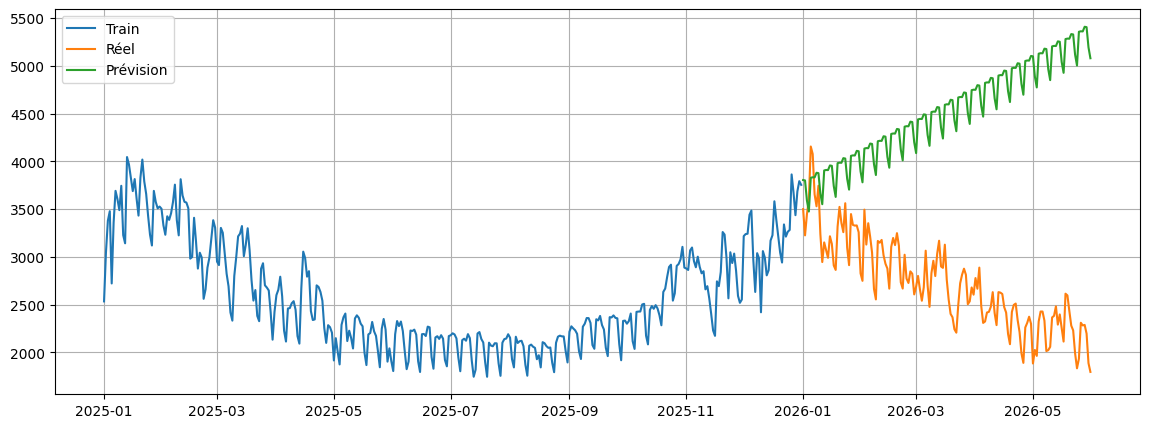

In [12]:
from pmdarima import auto_arima

model_a2 = auto_arima(
    train,
    seasonal=True,
    m=7,

    start_p=0,
    start_q=0,
    max_p=3,
    max_q=3,

    start_P=0,
    start_Q=0,
    max_P=1,
    max_Q=1,

    d=1,
    D=1,

    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,

    with_intercept=False,
    information_criterion="aic"
)

print(model_a2.summary())

# Prévision

forecast = model_a2.predict(
    n_periods=len(valid)
)

forecast = pd.Series(
    forecast,
    index=valid.index
)

# Évaluation

mae = mean_absolute_error(valid, forecast)
rmse = np.sqrt(mean_squared_error(valid, forecast))

mape = (
    np.abs((valid - forecast) / valid)
    .mean()
    * 100
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Visualisation

plt.figure(figsize=(14, 5))

plt.plot(train.loc["2025-01-01":], label="Train")
plt.plot(valid, label="Réel")
plt.plot(forecast, label="Prévision")

plt.legend()
plt.grid()
plt.show()

Performing stepwise search to minimize aic
 ARIMA(1,1,1)(1,1,1)[7]             : AIC=inf, Time=12.50 sec
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=29078.972, Time=0.45 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=28464.981, Time=2.99 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=27809.585, Time=4.56 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=29064.328, Time=0.51 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=27809.638, Time=8.16 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=28460.613, Time=3.56 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=27834.004, Time=2.65 sec
 ARIMA(1,1,1)(0,1,1)[7]             : AIC=inf, Time=10.47 sec
 ARIMA(0,1,2)(0,1,1)[7]             : AIC=inf, Time=8.64 sec
 ARIMA(1,1,0)(0,1,1)[7]             : AIC=27816.715, Time=4.89 sec
 ARIMA(1,1,2)(0,1,1)[7]             : AIC=inf, Time=13.83 sec
 ARIMA(0,1,1)(0,1,1)[7] intercept   : AIC=27811.576, Time=5.21 sec

Best model:  ARIMA(0,1,1)(0,1,1)[7]          
Total fit time: 78.428 seconds
                             

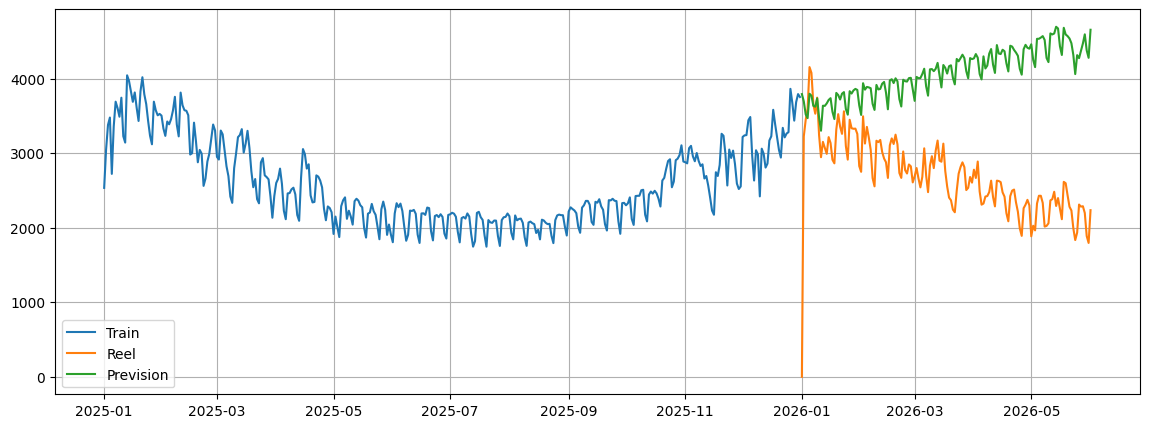

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# PREPARATION DES DONNEES CONSO + METEO

df_conso = pd.read_csv("data/brest_metropole_daily.csv", parse_dates=["date"])
df_meteo = pd.read_csv("data/brest_meteo_daily.csv", parse_dates=["date"])

df_model = (
    df_conso[["date", "conso_mwh"]]
    .merge(df_meteo[["date", "temp_moy_c"]], on="date", how="inner")
    .sort_values("date")
    .set_index("date")
)

# Cible et variable exogene

ts = df_model["conso_mwh"]
exog = df_model[["temp_moy_c"]]

# SPLIT

train = ts.loc["2020-01-01":"2025-12-31"]
valid = ts.loc["2026-01-01":]
X_train = exog.loc[train.index]
X_valid = exog.loc[valid.index]

# Recherche automatique SARIMA avec exogene

model_a3 = auto_arima(
    train,
    X=X_train,
    seasonal=True,
    m=7,

    start_p=1,
    start_q=1,
    max_p=3,
    max_q=3,

    start_P=1,
    start_Q=1,
    max_P=1,
    max_Q=1,

    d=1,
    D=1,

    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,

    with_intercept=False,
    information_criterion="aic"
)

print(model_a3.summary())

# Prevision

forecast = model_a3.predict(
    n_periods=len(valid),
    X=X_valid
)

forecast = pd.Series(
    forecast,
    index=valid.index
)

# Evaluation

mae = mean_absolute_error(valid, forecast)
rmse = np.sqrt(mean_squared_error(valid, forecast))

mape = (
    np.abs((valid - forecast) / valid)
    .mean()
    * 100
)

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Visualisation

plt.figure(figsize=(14, 5))
plt.plot(train.loc["2025-01-01":], label="Train")
plt.plot(valid, label="Reel")
plt.plot(forecast, label="Prevision")

plt.legend()
plt.grid()
plt.show()


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[7]             : AIC=24312.396, Time=1.05 sec
 ARIMA(1,1,0)(1,1,0)[7]             : AIC=23789.168, Time=5.95 sec
 ARIMA(0,1,1)(0,1,1)[7]             : AIC=23249.667, Time=9.00 sec
 ARIMA(0,1,1)(0,1,0)[7]             : AIC=24298.804, Time=1.07 sec
 ARIMA(0,1,1)(1,1,1)[7]             : AIC=23251.186, Time=11.02 sec
 ARIMA(0,1,1)(0,1,2)[7]             : AIC=23251.205, Time=17.15 sec
 ARIMA(0,1,1)(1,1,0)[7]             : AIC=23784.731, Time=4.67 sec
 ARIMA(0,1,1)(1,1,2)[7]             : AIC=23253.606, Time=15.83 sec
 ARIMA(0,1,0)(0,1,1)[7]             : AIC=23268.951, Time=4.27 sec
 ARIMA(1,1,1)(0,1,1)[7]             : AIC=inf, Time=15.10 sec
 ARIMA(0,1,2)(0,1,1)[7]             : AIC=23213.684, Time=10.69 sec
 ARIMA(0,1,2)(0,1,0)[7]             : AIC=24283.620, Time=1.43 sec
 ARIMA(0,1,2)(1,1,1)[7]             : AIC=23215.489, Time=15.78 sec
 ARIMA(0,1,2)(0,1,2)[7]             : AIC=inf, Time=10.80 sec
 ARIMA(0,1,2)(1,1,0)[7] 

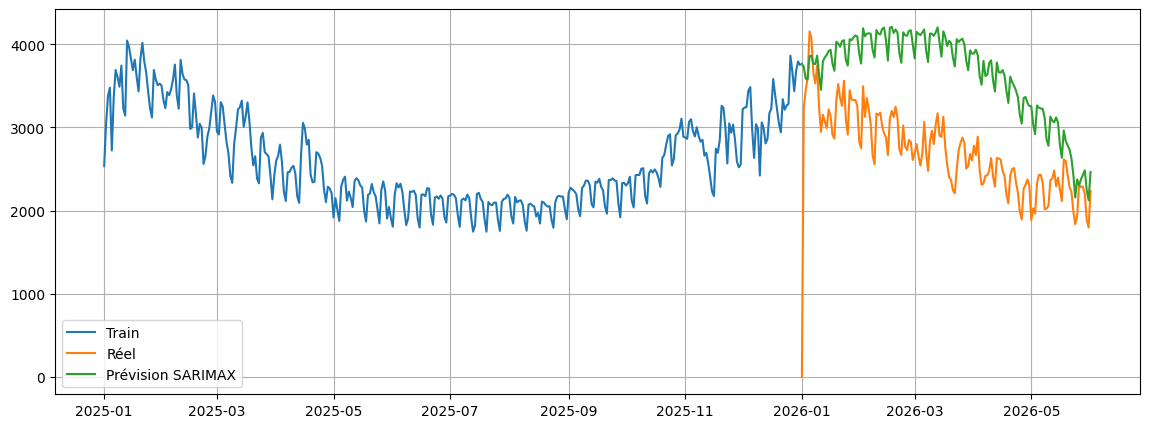

['models/model_sarimax_metadata.pkl']

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from pathlib import Path
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# MODELE A3 BIS - Auto SARIMAX avec température + saisonnalité annuelle explicite

df_sarimax = df_model.copy()

target_col = "conso_mwh"

# Features calendaires annuelles
df_sarimax["dayofyear"] = df_sarimax.index.dayofyear
df_sarimax["sin_year"] = np.sin(2 * np.pi * df_sarimax["dayofyear"] / 365.25)
df_sarimax["cos_year"] = np.cos(2 * np.pi * df_sarimax["dayofyear"] / 365.25)

# Lag annuel
df_sarimax["lag_365"] = df_sarimax[target_col].shift(365)

exog_cols = [
    "temp_moy_c",
    "sin_year",
    "cos_year",
    "lag_365",
]

data_sarimax = df_sarimax[[target_col] + exog_cols].dropna()

y = data_sarimax[target_col]
X = data_sarimax[exog_cols]

# Split temporel
y_train = y.loc["2020-01-01":"2025-12-31"]
y_valid = y.loc["2026-01-01":]

X_train = X.loc[y_train.index]
X_valid = X.loc[y_valid.index]

# Entraînement Auto-SARIMAX
model_sarimax = auto_arima(
    y=y_train,
    X=X_train,
    seasonal=True,
    m=7,
    start_p=0,
    start_q=0,
    max_p=4,
    max_q=4,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=1,
    D=1,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
    with_intercept=False,
    information_criterion="aic"
)

print(model_sarimax.summary())

# Prévision
forecast = model_sarimax.predict(
    n_periods=len(y_valid),
    X=X_valid
)

forecast = pd.Series(
    forecast,
    index=y_valid.index,
    name="forecast_sarimax"
)

# Évaluation
mae = mean_absolute_error(y_valid, forecast)
rmse = np.sqrt(mean_squared_error(y_valid, forecast))
mape = np.mean(np.abs((y_valid - forecast) / y_valid)) * 100

print("SARIMAX hebdomadaire avec température + saisonnalité annuelle")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(y_train.loc["2025-01-01":], label="Train")
plt.plot(y_valid, label="Réel")
plt.plot(forecast, label="Prévision SARIMAX")
plt.legend()
plt.grid()
plt.show()

# Sauvegarde
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

sarimax_metadata = {
    "model_type": "Auto-SARIMAX",
    "target": target_col,
    "exog_cols": exog_cols,
    "order": model_sarimax.order,
    "seasonal_order": model_sarimax.seasonal_order,
    "seasonality": "weekly",
    "m": 7,
    "features": {
        "calendar": ["sin_year", "cos_year"],
        "lags": ["lag_365"],
        "weather": ["temp_moy_c"],
    },
}

joblib.dump(model_sarimax, MODELS_DIR / "model_sarimax.pkl")
joblib.dump(sarimax_metadata, MODELS_DIR / "model_sarimax_metadata.pkl")


In [15]:
import joblib
from pathlib import Path

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

joblib.dump(model_a1, MODELS_DIR / "arima1_conso_mwh.pkl")
joblib.dump(model_a2, MODELS_DIR / "arima_auto_conso_mwh.pkl")
joblib.dump(model_a3, MODELS_DIR / "sarima_temp_moy_c_conso_mwh.pkl")
joblib.dump(model_sarimax, MODELS_DIR / "sarimax_model.joblib")
joblib.dump(sarimax_metadata, MODELS_DIR / "sarimax_metadata.joblib")


['models/sarimax_metadata.joblib']